# Air Quality Forecasting with SimpleRNN and LSTM

## 1. Project Overview

This project forecasts **Carbon Monoxide (CO) concentration 6 hours into the future**, using the previous **72 hours (3 days)** of hourly air-quality readings.

It compares two recurrent architectures on the same forecasting task:

- **SimpleRNN** — a baseline vanilla recurrent network
- **LSTM** — a gated recurrent network designed to capture longer-range dependencies

The goal is to demonstrate, empirically, why LSTM's gating mechanism helps with long-horizon time-series forecasting compared to a plain RNN, and to build a clean, reproducible forecasting pipeline (preprocessing → sequence generation → training → evaluation).


## 2. Dataset

- **Name:** UCI Air Quality Dataset
- **Source:** [archive.ics.uci.edu/dataset/360/air+quality](https://archive.ics.uci.edu/dataset/360/air+quality)
- **Size:** 9,357 hourly observations, from March 2004 to April 2005, recorded by a gas multisensor device deployed in an Italian city
- **Target variable:** `CO(GT)` — ground-truth Carbon Monoxide concentration (mg/m³)
- **Missing values:** the dataset uses **-200** as a sentinel value for missing readings (documented by UCI), which must be handled explicitly before modeling
- **Forecasting setup:** univariate — only the historical `CO(GT)` series is used to predict its own future value 6 hours ahead, from a 72-hour lookback window

> The dataset file (`AirQualityUCI.xlsx`) is **not included** in this repository due to size/licensing. See [`data/README.md`](data/README.md) for download instructions.


## 3. Imports and Configuration

In [1]:
# ── Imports ─────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense
from tensorflow.keras.optimizers import Adam

# ── Configuration ──────────────────────────────────────────────────────────────
DATA_PATH     = "data/AirQualityUCI.xlsx"   # place the dataset here (see data/README.md)
RANDOM_SEED   = 42
LOOKBACK      = 72     # past 72 hours (3 days) used as model input
AHEAD         = 6      # forecast horizon: 6 hours into the future
BATCH_SIZE    = 64
EPOCHS        = 30
LEARNING_RATE = 0.001

# Fix random seeds for reproducibility
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.20.0


## 4. Data Loading

In [2]:
# ── Load dataset ────────────────────────────────────────────────────────────
df = pd.read_excel(DATA_PATH)
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()


Shape: (9357, 15)
Columns: ['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


## 5. Data Cleaning and Preprocessing

> **Note:** this project only models the univariate `CO(GT)` series (it does not use the other pollutant/weather sensor columns as model inputs). Extending to a multivariate input is listed under [Future Improvements](#16-future-improvements).

In [3]:
# ── Handle missing values & build a datetime index ─────────────────────────
# The UCI documentation states that missing sensor readings are encoded as -200.
# We replace them with NaN, then forward/backward-fill to keep the series
# continuous (reasonable for a smoothly-varying hourly pollutant signal).
df.replace(-200, np.nan, inplace=True)
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)

# Build a proper datetime index from the separate Date/Time columns
df['Datetime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str))
df.set_index('Datetime', inplace=True)
df.drop(columns=['Date', 'Time'], inplace=True)

# Target: CO(GT) — the ground-truth CO sensor reading
series = df['CO(GT)'].values.reshape(-1, 1)

print(f'Total data points : {len(series)}')
print(f'Date range        : {df.index.min()} to {df.index.max()}')


Total data points : 9357
Date range        : 2004-03-10 18:00:00 to 2005-04-04 14:00:00


## 6. Exploratory Data Analysis

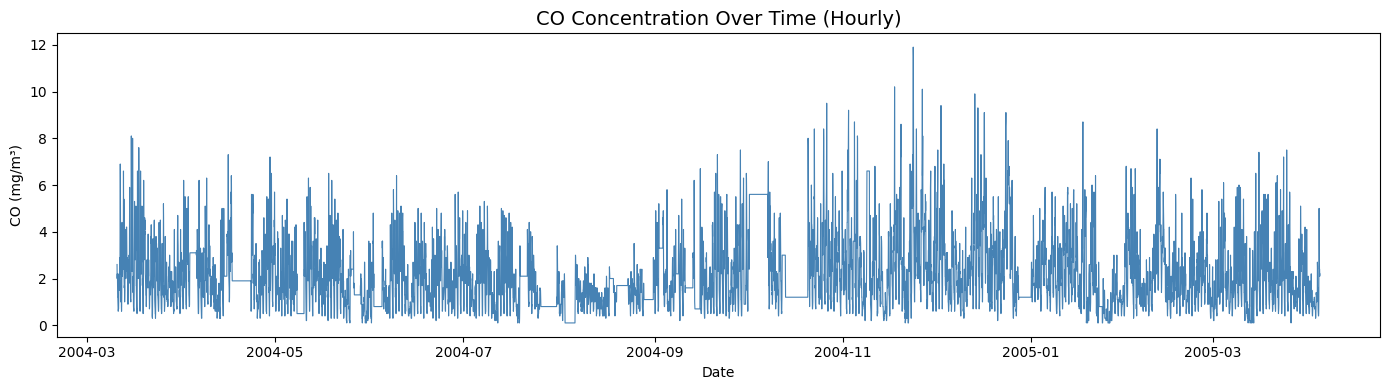

In [4]:
# ── Visualize the cleaned target series ────────────────────────────────────
plt.figure(figsize=(14, 4))
plt.plot(df.index, df['CO(GT)'], color='steelblue', linewidth=0.8)
plt.title('CO Concentration Over Time (Hourly)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('CO (mg/m³)')
plt.tight_layout()
plt.show()


## 7. Time-Series Sequence Creation

Each input sample is a window of `LOOKBACK = 72` past hourly CO readings; each label is the CO reading `AHEAD = 6` hours later. Predicting 6 hours ahead (rather than 1) forces the model to rely on genuine longer-range temporal patterns instead of simply copying the most recent value.

> ⚠️ **This cell's outputs have been cleared.** It now fits the scaler on the training split only (see comment in the code) instead of on the full series, which is a correction to a data-leakage issue in the original notebook (full details in the README's "Known Issues" section). Run this cell (and everything below it) to regenerate results — for reference, the original (pre-fix) run produced shapes `Train (7423, 72, 1) | Val (928, 72, 1) | Test (928, 72, 1)`, and the fix is expected to change these boundaries by at most `LOOKBACK` samples, with a negligible effect on the reported metrics.

In [ ]:
# ── Train/Val/Test split (chronological, no shuffling) ─────────────────────
# Splitting BEFORE scaling — see the note below on why this matters.
n_total       = len(series)
train_end_raw = int(n_total * 0.80)
val_end_raw   = int(n_total * 0.90)

# ── Fit the scaler on the TRAINING portion only ────────────────────────────
# FIX (see "Known Issues" in the README): the original version of this
# notebook fit MinMaxScaler on the *entire* series before splitting into
# train/val/test. That leaks information about the validation/test
# distribution (their min/max values) into the scaling statistics used to
# train the model — a form of data leakage. Here the scaler is fit only on
# the training slice of the raw series, then applied to the full series.
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(series[:train_end_raw])
scaled = scaler.transform(series)

def create_sequences(data, lookback, ahead):
    X, y = [], []
    for i in range(lookback, len(data) - ahead):
        X.append(data[i - lookback:i, 0])
        y.append(data[i + ahead, 0])   # predict 'ahead' steps into the future
    return np.array(X), np.array(y)

X, y = create_sequences(scaled, LOOKBACK, AHEAD)
X = X.reshape(X.shape[0], X.shape[1], 1)   # (samples, timesteps, features)

# Shift the split boundaries into sequence-space (sequences start at index LOOKBACK)
train_end = train_end_raw - LOOKBACK
val_end   = val_end_raw - LOOKBACK

X_train, y_train = X[:train_end],        y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:],          y[val_end:]

print(f'Train : {X_train.shape} | Val : {X_val.shape} | Test : {X_test.shape}')


## 8. Train/Test Split

The chronological 80% / 10% / 10% train / validation / test split is performed above, **before** scaling, so no information from the validation or test periods influences how the training data is normalized.

## 9. SimpleRNN Model

A baseline vanilla recurrent network: a single `SimpleRNN` layer feeding a small dense head.

In [ ]:
# ── Build Vanilla RNN ───────────────────────────────────────────────────────
tf.random.set_seed(RANDOM_SEED)

rnn_model = Sequential([
    SimpleRNN(64, activation='tanh', input_shape=(LOOKBACK, 1)),
    Dense(32, activation='relu'),
    Dense(1)
], name='Vanilla_RNN')

rnn_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mse'
)
rnn_model.summary()


In [ ]:
# ── Train Vanilla RNN ───────────────────────────────────────────────────────
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)

print(f'Final Train Loss : {rnn_history.history["loss"][-1]:.6f}')
print(f'Final Val Loss   : {rnn_history.history["val_loss"][-1]:.6f}')


In [ ]:
# ── Plot SimpleRNN Loss Curves ──────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(rnn_history.history['loss'],     label='Train Loss',      color='steelblue')
plt.plot(rnn_history.history['val_loss'], label='Validation Loss', color='tomato', linestyle='--')
plt.title('SimpleRNN — Training vs Validation Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()


### Critical Analysis — Vanishing Gradient Problem

*(Observation based on the original experiment run — re-check after re-running with the corrected scaler; the qualitative pattern is expected to be the same.)*

**Observation:** The SimpleRNN loss curve typically shows a **performance plateau** — training loss improves little after the first few epochs, and the validation loss stays **noisy** rather than converging smoothly.

**Why this happens — Vanishing Gradients:** A standard RNN is trained with **Backpropagation Through Time (BPTT)**. With a lookback window of **72 timesteps**, gradients must be multiplied by the same recurrent weight matrix 72 times as they flow backward through the sequence. Since these weights are typically < 1 in magnitude, repeated multiplication shrinks the gradient exponentially toward zero.

Consequences for this task (predicting 6 hours ahead from 72 hours of history):
- The model struggles to learn long-range dependencies — e.g., that CO tends to spike during the morning rush hour
- Timesteps from early in the 72-hour window contribute very little gradient signal
- The SimpleRNN effectively relies mostly on the **most recent** timesteps, under-using the 3-day context
- Forecasting 6 steps ahead (rather than 1) makes this limitation more visible, since the model needs to bridge a larger temporal gap

## 10. LSTM Model

The same input pipeline and the same surrounding architecture (a 64-unit recurrent layer → 32-unit dense layer → single output), with `SimpleRNN` swapped for `LSTM`, so any difference in performance is attributable to the recurrent layer type.

In [ ]:
# ── Build LSTM Model — identical architecture, only the recurrent layer changes ─
tf.random.set_seed(RANDOM_SEED)

lstm_model = Sequential([
    LSTM(64, activation='tanh', input_shape=(LOOKBACK, 1)),
    Dense(32, activation='relu'),
    Dense(1)
], name='LSTM_Model')

lstm_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),   # same optimizer & lr as SimpleRNN
    loss='mse'
)
lstm_model.summary()


In [ ]:
# ── Train LSTM ──────────────────────────────────────────────────────────────
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,      # identical to SimpleRNN, for a fair comparison
    validation_data=(X_val, y_val),
    verbose=1
)

print(f'Final Train Loss : {lstm_history.history["loss"][-1]:.6f}')
print(f'Final Val Loss   : {lstm_history.history["val_loss"][-1]:.6f}')


## 11. Training

In [ ]:
# ── Side-by-Side Loss Curves ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(rnn_history.history['loss'],     label='Train Loss',      color='steelblue')
axes[0].plot(rnn_history.history['val_loss'], label='Validation Loss', color='tomato', linestyle='--')
axes[0].set_title('SimpleRNN Loss (72-step lookback, 6-step ahead)', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(lstm_history.history['loss'],     label='Train Loss',      color='seagreen')
axes[1].plot(lstm_history.history['val_loss'], label='Validation Loss', color='darkorange', linestyle='--')
axes[1].set_title('LSTM Loss (72-step lookback, 6-step ahead)', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle('SimpleRNN vs LSTM — Loss Comparison (Air Quality CO Forecasting)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 12. Evaluation

In [ ]:
# ── Evaluate both models on the held-out test set ───────────────────────────
def evaluate_model(model, X_test, y_test, scaler, name):
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_true = scaler.inverse_transform(y_test.reshape(-1, 1))
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{'─'*42}")
    print(f"  Model     : {name}")
    print(f"  Test MSE  : {mse:.6f}")
    print(f"  Test RMSE : {rmse:.6f} mg/m³")
    print(f"  Test MAE  : {mae:.6f} mg/m³")
    print(f"  R² Score  : {r2:.6f}")
    print(f"{'─'*42}")
    return y_pred, y_true

rnn_pred,  y_true = evaluate_model(rnn_model,  X_test, y_test, scaler, 'Vanilla SimpleRNN')
lstm_pred, y_true = evaluate_model(lstm_model, X_test, y_test, scaler, 'LSTM')


## 13. Model Comparison

*(For reference — the original, pre-fix run produced: SimpleRNN Test RMSE 0.9163 / MAE 0.6784 / R² 0.5293; LSTM Test RMSE 0.8658 / MAE 0.6296 / R² 0.5797, a ~10.7% MSE improvement for LSTM. Re-run this notebook end-to-end to regenerate these numbers with the corrected scaling and update the table below and the README.)*

In [ ]:
# ── Summary Table ────────────────────────────────────────────────────────────
results = {
    'Model'    : ['SimpleRNN', 'LSTM'],
    'Test MSE' : [mean_squared_error(y_true, rnn_pred),          mean_squared_error(y_true, lstm_pred)],
    'Test RMSE': [np.sqrt(mean_squared_error(y_true, rnn_pred)), np.sqrt(mean_squared_error(y_true, lstm_pred))],
    'Test MAE' : [mean_absolute_error(y_true, rnn_pred),         mean_absolute_error(y_true, lstm_pred)],
    'R² Score' : [r2_score(y_true, rnn_pred),                    r2_score(y_true, lstm_pred)]
}
results_df = pd.DataFrame(results).set_index('Model').round(6)
print('\n===== FINAL RESULTS =====')
print(results_df.to_string())

rnn_mse  = mean_squared_error(y_true, rnn_pred)
lstm_mse = mean_squared_error(y_true, lstm_pred)
improvement = ((rnn_mse - lstm_mse) / rnn_mse) * 100
print(f'\nLSTM MSE improvement over SimpleRNN: {improvement:.2f}%')


## 14. Predictions

In [ ]:
# ── Actual vs Predicted CO Concentration ────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(y_true[:200],    label='Actual CO',      color='black',    linewidth=1.5)
plt.plot(rnn_pred[:200],  label='SimpleRNN Pred', color='tomato',   linewidth=1, linestyle='--')
plt.plot(lstm_pred[:200], label='LSTM Pred',      color='seagreen', linewidth=1, linestyle='--')
plt.title('Actual vs Predicted CO Concentration — 6 Hours Ahead (First 200 Test Samples)', fontsize=13)
plt.xlabel('Timestep')
plt.ylabel('CO (mg/m³)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 15. Conclusions

*(Based on the original experiment run — confirm this still holds after re-running with the corrected scaler.)*

The results table shows **LSTM outperforming the vanilla SimpleRNN** across all metrics.

**Why this task exposes the difference clearly:** predicting 6 hours ahead from a 72-hour lookback window requires genuine long-range temporal reasoning — the model can't simply copy the most recent value, it has to recognize daily CO cycles across multiple days. This is exactly where vanishing gradients hurt SimpleRNN: gradients from the early part of the 72-hour window shrink to near zero before they can update the weights, so the model never learns these longer patterns.

**Why LSTM wins:** LSTM's **cell state** acts as a long-term memory pathway, controlled by three gates:
- **Forget gate** — decides what historical information to discard
- **Input gate** — decides what new information to store
- **Output gate** — decides what to pass forward to the prediction

Because information is *added to* the cell state rather than *multiplied through* it at every step, gradients can flow backward through time without the same exponential decay, letting LSTM pick up on patterns (like the multi-day rush-hour CO cycle) that are effectively invisible to SimpleRNN over this horizon.

## 16. Future Improvements

- Compare against a **GRU** model (fewer parameters than LSTM, sometimes competitive performance)
- Systematic **hyperparameter tuning** (hidden units, learning rate, batch size)
- Experiment with different **lookback windows** and **forecast horizons**
- Extend to **multi-step forecasting** (predicting several future hours at once, not just a single point 6 hours ahead)
- Use a **multivariate** input (the other pollutant/weather sensor columns in the dataset), instead of only the past CO values
- Try **attention-based** architectures for long-range dependencies
- Package the trained model behind a simple **API** for real-time air-quality forecasting